# **City Landscape in Sight: A Crowdsourced Framework for Unlocking Urban-Scale Window View Perceptions from Real Estate Imagery**

**Authors:** [Chucai Peng](https://ual.sg/author/chucai-peng/)†, [Sijie Yang](https://sijie-yang.com)†, Ang Liu, Yang Xiang, Zhixiang Zhou, [Filip Biljecki](https://filipbiljecki.com)* 

by [Urban Analytics Lab](https://ual.sg), [Department of Architecture](https://cde.nus.edu.sg/arch/), [College of Design and Engineering](https://cde.nus.edu.sg), [National University of Singapore](https://www.nus.edu.sg)


---

(† co-first authors, * corresponding authors)

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

# Code_6_WVI Perception Inference Analytics

This notebook benchmarks multiple regression models for predicting WVI perception scores from geospatial and visual features, evaluates their performance using R² and RMSE, checks multicollinearity (Spearman correlation and VIF), and analyses feature attributions with SHAP.

Data source used in this notebook:
- `data/data.csv` (perception and geospatial features for each WVI)

## 0. Plotting Configuration

Run plotting configuration first - Set up the overall style of figures.

In [1]:
import matplotlib as mpl
import seaborn as sns

sns.set_theme(context="paper", style="white", font_scale=0.9)

mpl.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 600,
    "figure.autolayout": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.linewidth": 0.6,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "legend.fontsize": 7,
    "legend.frameon": False,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

OKABE_ITO = [
    "#E69F00",
    "#56B4E9",
    "#009E73",
    "#F0E442",
    "#0072B2",
    "#D55E00",
    "#CC79A7",
    "#000000",
]
sns.set_palette(OKABE_ITO)

INCH_PER_MM = 1.0 / 25.4
COL_WIDTH = 89 * INCH_PER_MM
DOUBLE_COL_WIDTH = 183 * INCH_PER_MM
FIG_HEIGHT_SMALL = 2.2
FIG_HEIGHT_MEDIUM = 2.8
FIG_HEIGHT_TALL = 3.4

from pathlib import Path

def savefig_all(fig, basename, png_dpi=300, tight=True):
    out_base = Path(basename)
    kwargs = {"bbox_inches": "tight", "pad_inches": 0.01} if tight else {}
    fig.savefig(str(out_base.with_suffix(".png")), dpi=png_dpi, **kwargs)
    fig.savefig(str(out_base.with_suffix(".svg")), **kwargs)

## 1. Inference Modelling
#### Load data

In [3]:
import pandas as pd

df = pd.read_csv('data/data.csv')

perception_cols = ['Prefer', 'Monotonous', 'Quiet', 'Extensive', 'Vivid', 'Oppressive']
feature_cols = [
    'WV_Sky', 'WV_Highrisebuilding', 'WV_Lowrisebuilding', 'WV_Grass', 'WV_Hardground',
    'WV_Tree', 'WV_Water', 'WV_Railing', 'WV_Road', 'WV_Barrenland', 'WV_Buildinginterior',
    'LC_Water', 'LC_Trees', 'LC_Crops', 'LC_Built_Area', 'LC_Bare_Ground', 'LC_Rangeland',
    'BD', 'FAR', 'BH', 'BH_SD', 'NDBI', 'NDVI'
]

Y = df[perception_cols]
X = df[feature_cols]

print(f"Dataset: {len(df)} samples, {len(feature_cols)} features, {len(perception_cols)} targets")
print(f"Features: {feature_cols}")
print(f"\nY descriptive statistics:")
print(Y.describe().T.to_string())

Dataset: 12334 samples, 23 features, 6 targets
Features: ['WV_Sky', 'WV_Highrisebuilding', 'WV_Lowrisebuilding', 'WV_Grass', 'WV_Hardground', 'WV_Tree', 'WV_Water', 'WV_Railing', 'WV_Road', 'WV_Barrenland', 'WV_Buildinginterior', 'LC_Water', 'LC_Trees', 'LC_Crops', 'LC_Built_Area', 'LC_Bare_Ground', 'LC_Rangeland', 'BD', 'FAR', 'BH', 'BH_SD', 'NDBI', 'NDVI']

Y descriptive statistics:
              count      mean       std       min       25%       50%       75%        max
Prefer      12334.0  2.526892  1.238539 -0.065136  1.475667  2.440140  3.524266   6.708228
Monotonous  12334.0  2.704725  1.035417  0.106148  1.911348  2.615048  3.457839  19.024019
Quiet       12334.0  2.429780  0.964921  0.298925  1.705863  2.321928  3.037252  20.108046
Extensive   12334.0  2.346173  1.148670  0.001341  1.349931  2.336194  3.275226   6.853618
Vivid       12334.0  1.942051  1.095686  0.074462  1.045465  1.723001  2.674803   6.531858
Oppressive  12334.0  2.252410  0.942978 -0.003368  1.512888  2.309

#### Multicollinearity — Spearman Correlation & VIF

Before fitting inference models, we examine pairwise associations among the 23 built-environment predictors using **Spearman rank correlation** and **Variance Inflation Factor (VIF)**.

**VIF is reported twice:**
1. **All 23 predictors** — includes all window-view (`WV_*`) and land-cover (`LC_*`) proportion classes. Because each group sums to ≈1 (compositional data), VIF is artificially inflated to very large values.
2. **Reference-dropped sets** — standard compositional practice: drop one class per group (`WV_Sky`, `LC_Water`) before VIF, then report subgroup tables for WV, LC, urban form, and the combined 21-feature inference set used conceptually in Table 8.

Variables with VIF > 5 indicate problematic multicollinearity for **OLS**; we therefore use regularised and ensemble methods (Ridge, Lasso, Random Forest, XGBoost) in the benchmark below (Reviewer 1, comment [8]).



Spearman correlation matrix: 23 × 23
|ρ| ≥ 0.7 pairs: 4
feature_a     feature_b  spearman_rho
       BH         BH_SD         0.852
      FAR            BH         0.849
       BD           FAR         0.808
 LC_Water LC_Built_Area        -0.794


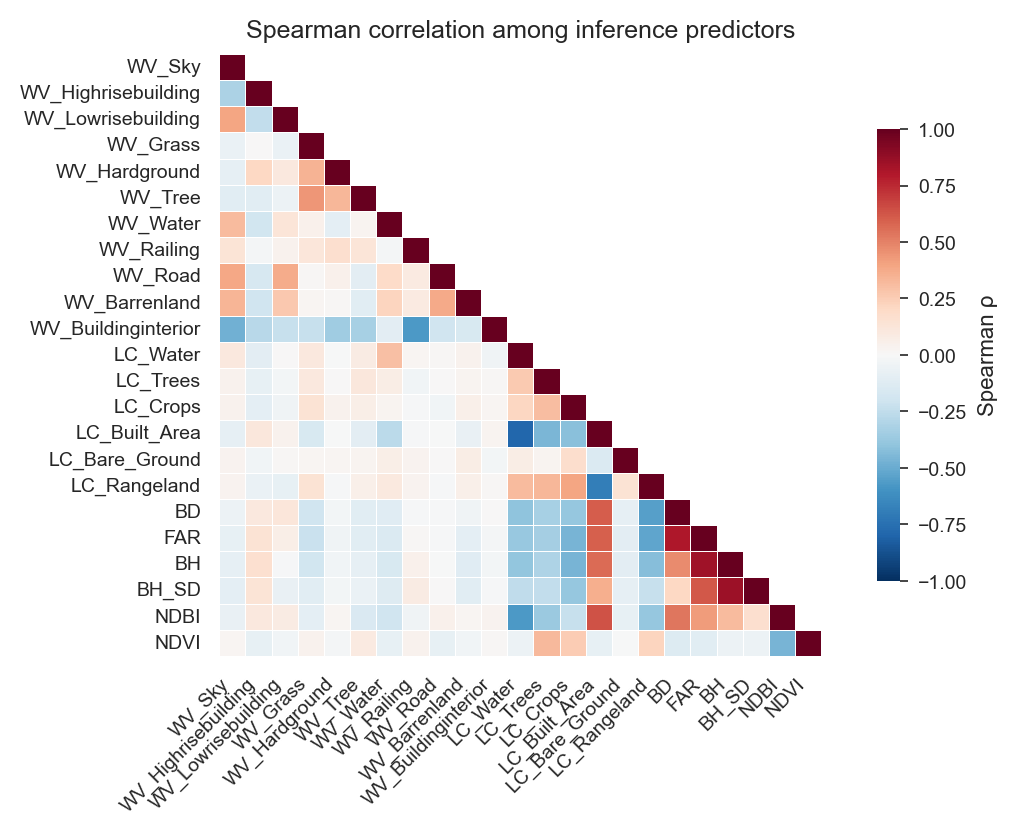

In [9]:
spearman_corr = X.corr(method='spearman')

out_dir = Path('model_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
spearman_corr.to_csv(out_dir / 'inference_spearman_correlation.csv')

# Strong pairwise correlations (|ρ| ≥ 0.7), upper triangle only
strong_pairs = []
for i, col_i in enumerate(feature_cols):
    for j in range(i + 1, len(feature_cols)):
        col_j = feature_cols[j]
        rho = spearman_corr.loc[col_i, col_j]
        if abs(rho) >= 0.7:
            strong_pairs.append({'feature_a': col_i, 'feature_b': col_j, 'spearman_rho': rho})

strong_corr_df = pd.DataFrame(strong_pairs).sort_values('spearman_rho', key=abs, ascending=False)
print(f'Spearman correlation matrix: {spearman_corr.shape[0]} × {spearman_corr.shape[1]}')
print(f'|ρ| ≥ 0.7 pairs: {len(strong_corr_df)}')
if len(strong_corr_df):
    print(strong_corr_df.to_string(index=False, float_format='%.3f'))

fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_TALL * 1.15))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)
sns.heatmap(
    spearman_corr,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.25,
    cbar_kws={'label': 'Spearman ρ', 'shrink': 0.75},
    ax=ax,
)
ax.set_title('Spearman correlation among inference predictors', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
savefig_all(fig, 'figures/code_6_spearman_correlation')


Compositional constraint (row sums ≈ 1):
  WV (11 classes): mean sum = 1.0000
  LC (6 classes): mean sum = 1.0000

VIF — all 23 predictors (compositional inflation expected)
            feature        VIF  high_vif
             WV_Sky   34745.68      True
WV_Highrisebuilding   29447.60      True
 WV_Lowrisebuilding    1032.05      True
           WV_Grass     281.15      True
      WV_Hardground     594.73      True
            WV_Tree    6013.25      True
           WV_Water      79.34      True
         WV_Railing   19438.55      True
            WV_Road     146.61      True
      WV_Barrenland      83.93      True
WV_Buildinginterior  935498.55      True
           LC_Water   15605.57      True
           LC_Trees    1226.11      True
           LC_Crops    2172.56      True
      LC_Built_Area 1999105.39      True
     LC_Bare_Ground      12.70      True
       LC_Rangeland    4468.08      True
                 BD      56.20      True
                FAR     119.93      True
      

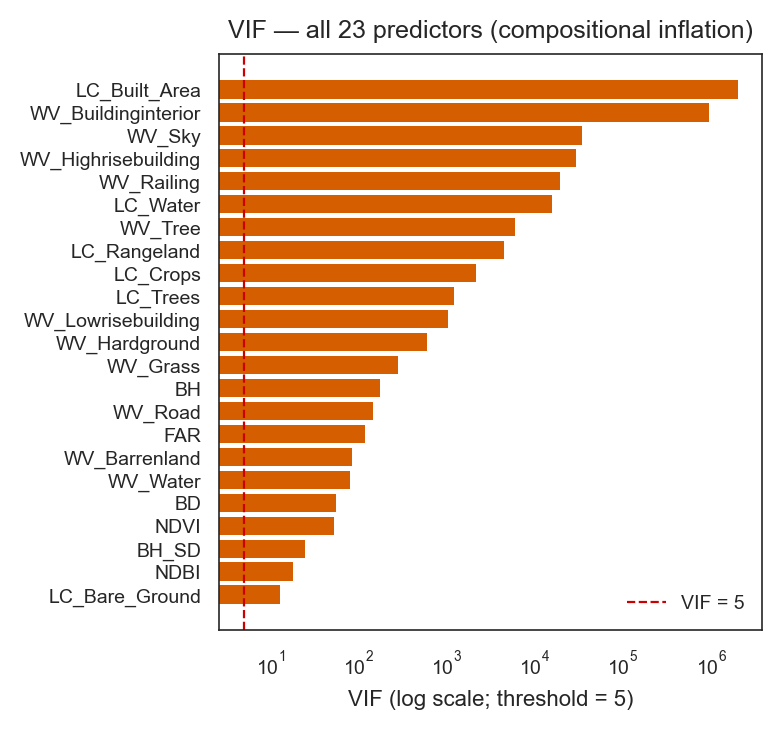

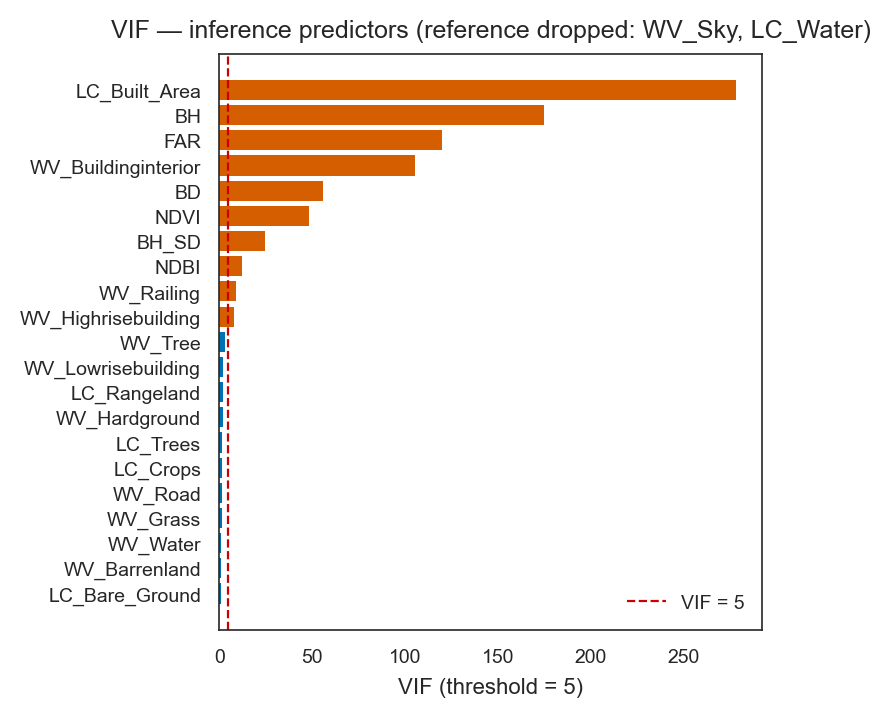

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

VIF_THRESHOLD = 5
WV_COLS = [c for c in feature_cols if c.startswith('WV_')]
LC_COLS = [c for c in feature_cols if c.startswith('LC_')]
URBAN_COLS = ['BD', 'FAR', 'BH', 'BH_SD', 'NDBI', 'NDVI']
WV_REF = 'WV_Sky'
LC_REF = 'LC_Water'


def compute_vif_df(cols, *, vif_set, dropped_reference=''):
    """VIF for a numeric predictor block (list preserves column order)."""
    cols = list(cols)
    X_sub = X[cols].astype(float)
    vifs = [variance_inflation_factor(X_sub.values, i) for i in range(len(cols))]
    return pd.DataFrame({
        'vif_set': vif_set,
        'feature': cols,
        'VIF': vifs,
        'high_vif': [v > VIF_THRESHOLD for v in vifs],
        'dropped_reference': dropped_reference,
    })


print('Compositional constraint (row sums ≈ 1):')
print(f"  WV ({len(WV_COLS)} classes): mean sum = {X[WV_COLS].sum(axis=1).mean():.4f}")
print(f"  LC ({len(LC_COLS)} classes): mean sum = {X[LC_COLS].sum(axis=1).mean():.4f}")

wv_cols = [c for c in WV_COLS if c != WV_REF]
lc_cols = [c for c in LC_COLS if c != LC_REF]
inference_ref_cols = wv_cols + lc_cols + URBAN_COLS

vif_frames = [
    compute_vif_df(feature_cols, vif_set='all_23_predictors'),
    compute_vif_df(wv_cols, vif_set='wv_compositional', dropped_reference=WV_REF),
    compute_vif_df(lc_cols, vif_set='lc_compositional', dropped_reference=LC_REF),
    compute_vif_df(URBAN_COLS, vif_set='urban_form'),
    compute_vif_df(
        inference_ref_cols,
        vif_set='inference_reference_dropped',
        dropped_reference=f'{WV_REF}; {LC_REF}',
    ),
]
vif_all = pd.concat(vif_frames, ignore_index=True)
vif_all.to_csv(out_dir / 'inference_vif.csv', index=False)

# --- Print tables ---
def print_vif_block(df, title):
    print(f'\n{title}')
    print(df[['feature', 'VIF', 'high_vif']].to_string(index=False, float_format='%.2f'))
    n_high = int(df['high_vif'].sum())
    print(f'  VIF > {VIF_THRESHOLD}: {n_high} / {len(df)}')

print_vif_block(
    vif_all[vif_all['vif_set'] == 'all_23_predictors'],
    'VIF — all 23 predictors (compositional inflation expected)',
)
print_vif_block(
    vif_all[vif_all['vif_set'] == 'wv_compositional'],
    f'VIF — window-view proportions (reference dropped: {WV_REF})',
)
print_vif_block(
    vif_all[vif_all['vif_set'] == 'lc_compositional'],
    f'VIF — land-cover proportions (reference dropped: {LC_REF})',
)
print_vif_block(
    vif_all[vif_all['vif_set'] == 'urban_form'],
    'VIF — urban form / indices',
)
print_vif_block(
    vif_all[vif_all['vif_set'] == 'inference_reference_dropped'],
    f'VIF — combined inference set (21 features; references dropped: {WV_REF}, {LC_REF})',
)


def plot_vif_barh(df, *, title, basename, log_scale=False):
    fig, ax = plt.subplots(figsize=(COL_WIDTH, FIG_HEIGHT_TALL * 1.1))
    plot_df = df.sort_values('VIF', ascending=True)
    bar_colors = ['#D55E00' if v > VIF_THRESHOLD else '#0072B2' for v in plot_df['VIF']]
    ax.barh(plot_df['feature'], plot_df['VIF'], color=bar_colors, edgecolor='none')
    if log_scale:
        ax.set_xscale('log')
        xlabel = f'VIF (log scale; threshold = {VIF_THRESHOLD})'
    else:
        xlabel = f'VIF (threshold = {VIF_THRESHOLD})'
    ax.axvline(VIF_THRESHOLD, color='#CC0000', linestyle='--', linewidth=0.8, label=f'VIF = {VIF_THRESHOLD}')
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=9)
    ax.legend(loc='lower right', frameon=False)
    savefig_all(fig, basename)
    plt.show()


plot_vif_barh(
    vif_all[vif_all['vif_set'] == 'all_23_predictors'],
    title='VIF — all 23 predictors (compositional inflation)',
    basename='figures/code_6_vif_barplot_all_predictors',
    log_scale=True,
)
plot_vif_barh(
    vif_all[vif_all['vif_set'] == 'inference_reference_dropped'],
    title=f'VIF — inference predictors (reference dropped: {WV_REF}, {LC_REF})',
    basename='figures/code_6_vif_barplot',
    log_scale=False,
)



#### Model Regression Benchmark

We train and evaluate seven regression models: Ridge, Lasso, ElasticNet, PLS, Random Forest, SVR, and XGBoost.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.3, random_state=42
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 8633 samples | Test: 3701 samples


In [5]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from tqdm import tqdm

steps = [
    ('Ridge',        lambda: Ridge(alpha=1.0)),
    ('Lasso',        lambda: Lasso(alpha=0.1)),
    ('ElasticNet',   lambda: ElasticNet(alpha=0.1, l1_ratio=0.5)),
    ('PLS',          lambda: PLSRegression(n_components=min(10, X_train.shape[1]))),
    ('RandomForest', lambda: RandomForestRegressor(n_estimators=100, random_state=42)),
]

preds = {}
with tqdm(steps, desc='Training linear/ensemble models') as pbar:
    for name, model_fn in pbar:
        pbar.set_postfix(model=name)
        m = model_fn()
        m.fit(X_train, Y_train)
        preds[name] = m.predict(X_test)

Y_pred_ridge       = preds['Ridge']
Y_pred_lasso       = preds['Lasso']
Y_pred_elastic_net = preds['ElasticNet']
Y_pred_pls         = preds['PLS']
Y_pred_rf          = preds['RandomForest']

Y_pred_svr, Y_pred_xgb = [], []
targets = list(range(Y_train.shape[1]))
for i in tqdm(targets, desc='Training SVR & XGBoost per target'):
    svr = SVR(kernel='rbf')
    svr.fit(X_train, Y_train.iloc[:, i])
    Y_pred_svr.append(svr.predict(X_test))

    xgb_reg = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    xgb_reg.fit(X_train, Y_train.iloc[:, i])
    Y_pred_xgb.append(xgb_reg.predict(X_test))

Y_pred_svr = np.column_stack(Y_pred_svr)
Y_pred_xgb = np.column_stack(Y_pred_xgb)

print('All models trained.')

Training SVR & XGBoost per target: 100%|██████████| 6/6 [00:15<00:00,  2.64s/it]

All models trained.


#### Model Evaluation — R² and RMSE

In [6]:
from sklearn.metrics import r2_score, mean_squared_error

models = {
    'Ridge': Y_pred_ridge,
    'Lasso': Y_pred_lasso,
    'ElasticNet': Y_pred_elastic_net,
    'PLS': Y_pred_pls,
    'RandomForest': Y_pred_rf,
    'SVR': Y_pred_svr,
    'XGBoost': Y_pred_xgb,
}

r2_scores = pd.DataFrame(index=models.keys(), columns=perception_cols, dtype=float)
rmse_scores = pd.DataFrame(index=models.keys(), columns=perception_cols, dtype=float)

for model_name, Y_pred in models.items():
    for i, col in enumerate(perception_cols):
        y_true = Y_test[col]
        y_pred = Y_pred[:, i] if Y_pred.ndim == 2 else Y_pred
        r2_scores.loc[model_name, col] = r2_score(y_true, y_pred)
        rmse_scores.loc[model_name, col] = np.sqrt(mean_squared_error(y_true, y_pred))

print("R² Scores:")
print(r2_scores.astype(float).round(4).to_string())
print("\nRMSE Scores:")
print(rmse_scores.astype(float).round(4).to_string())

R² Scores:
              Prefer  Monotonous   Quiet  Extensive   Vivid  Oppressive
Ridge         0.7502      0.3764  0.4686     0.7595  0.4273      0.6599
Lasso         0.7142      0.3242  0.4082     0.7223  0.3678      0.6223
ElasticNet    0.7356      0.3535  0.4429     0.7435  0.4011      0.6384
PLS           0.7495      0.3766  0.4684     0.7590  0.4238      0.6600
RandomForest  0.7753      0.4402  0.5283     0.7981  0.5179      0.6869
SVR           0.7797      0.4537  0.5353     0.7971  0.5225      0.6973
XGBoost       0.7897      0.4736  0.5569     0.8158  0.5727      0.7111

RMSE Scores:
              Prefer  Monotonous   Quiet  Extensive   Vivid  Oppressive
Ridge         0.6139      0.8045  0.6925     0.5617  0.8238      0.5476
Lasso         0.6567      0.8374  0.7308     0.6036  0.8655      0.5770
ElasticNet    0.6316      0.8191  0.7090     0.5800  0.8424      0.5646
PLS           0.6148      0.8043  0.6926     0.5622  0.8262      0.5474
RandomForest  0.5823      0.7622  0.652

#### Model Visualisation — R² Heatmap

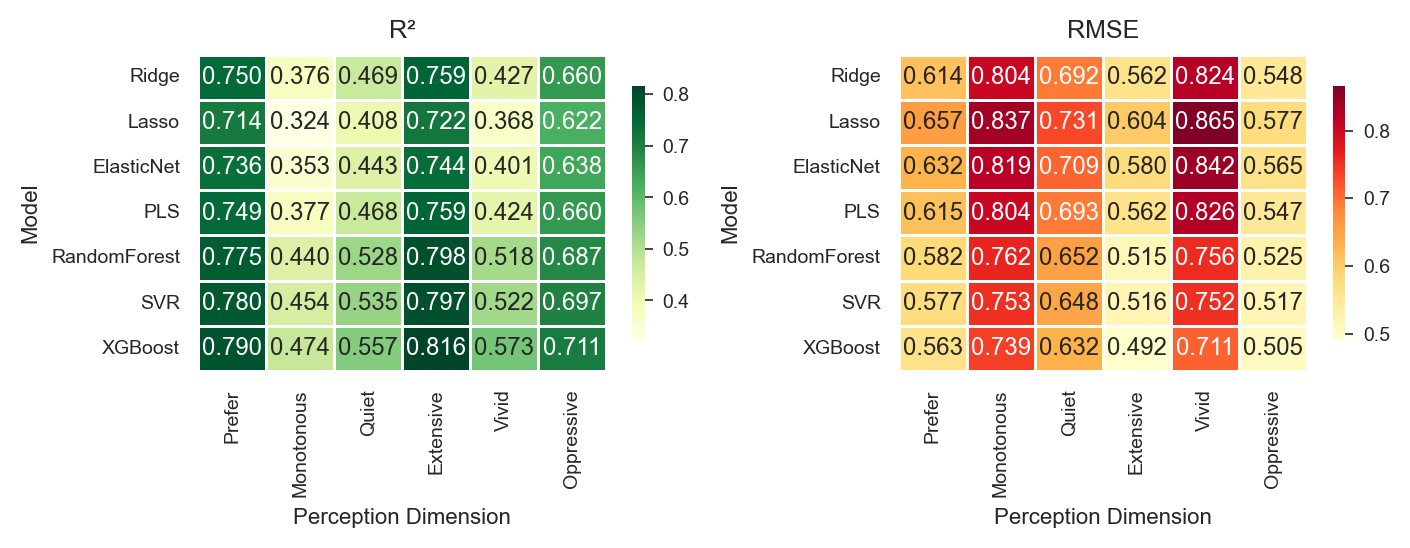

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_MEDIUM))

for ax, data, title in zip(axes,
                            [r2_scores.astype(float), rmse_scores.astype(float)],
                            ['R²', 'RMSE']):
    sns.heatmap(
        data,
        ax=ax,
        annot=True,
        fmt='.3f',
        cmap='YlOrRd' if title == 'RMSE' else 'YlGn',
        linewidths=0.4,
        cbar_kws={'shrink': 0.8},
    )
    ax.set_title(title)
    ax.set_xlabel('Perception Dimension')
    ax.set_ylabel('Model')

plt.tight_layout()
savefig_all(fig, 'figures/code_6_inference_model_heatmap')
plt.show()

## 2. SHAP Feature Attribution

XGBoost is fitted on the unscaled features (tree models are scale-invariant) for every perception dimension, and SHAP values are computed on the held-out test split.

#### Train XGBoost models and compute SHAP values

In [8]:
import shap

X_train_raw, X_test_raw, _, _ = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

shap_models = {}
explainers = {}
shap_values_dict = {}

for target in tqdm(perception_cols, desc='Training XGBoost & computing SHAP'):
    model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        objective='reg:squarederror',
        random_state=42,
    )
    model.fit(X_train_raw, Y_train[target])
    shap_models[target] = model

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_raw)
    explainers[target] = explainer
    shap_values_dict[target] = shap_values

print(f"Computed SHAP values for {len(perception_cols)} perception dimensions on {X_test_raw.shape[0]} test samples.")

Training XGBoost & computing SHAP: 100%|██████████| 6/6 [00:03<00:00,  1.73it/s]

Computed SHAP values for 6 perception dimensions on 3701 test samples.


#### SHAP Summary Plots

A 3×2 grid of violin SHAP summary plots, one per perception dimension, showing the top 10 contributing features. The colour bar on the right of each row represents the feature value (low to high).

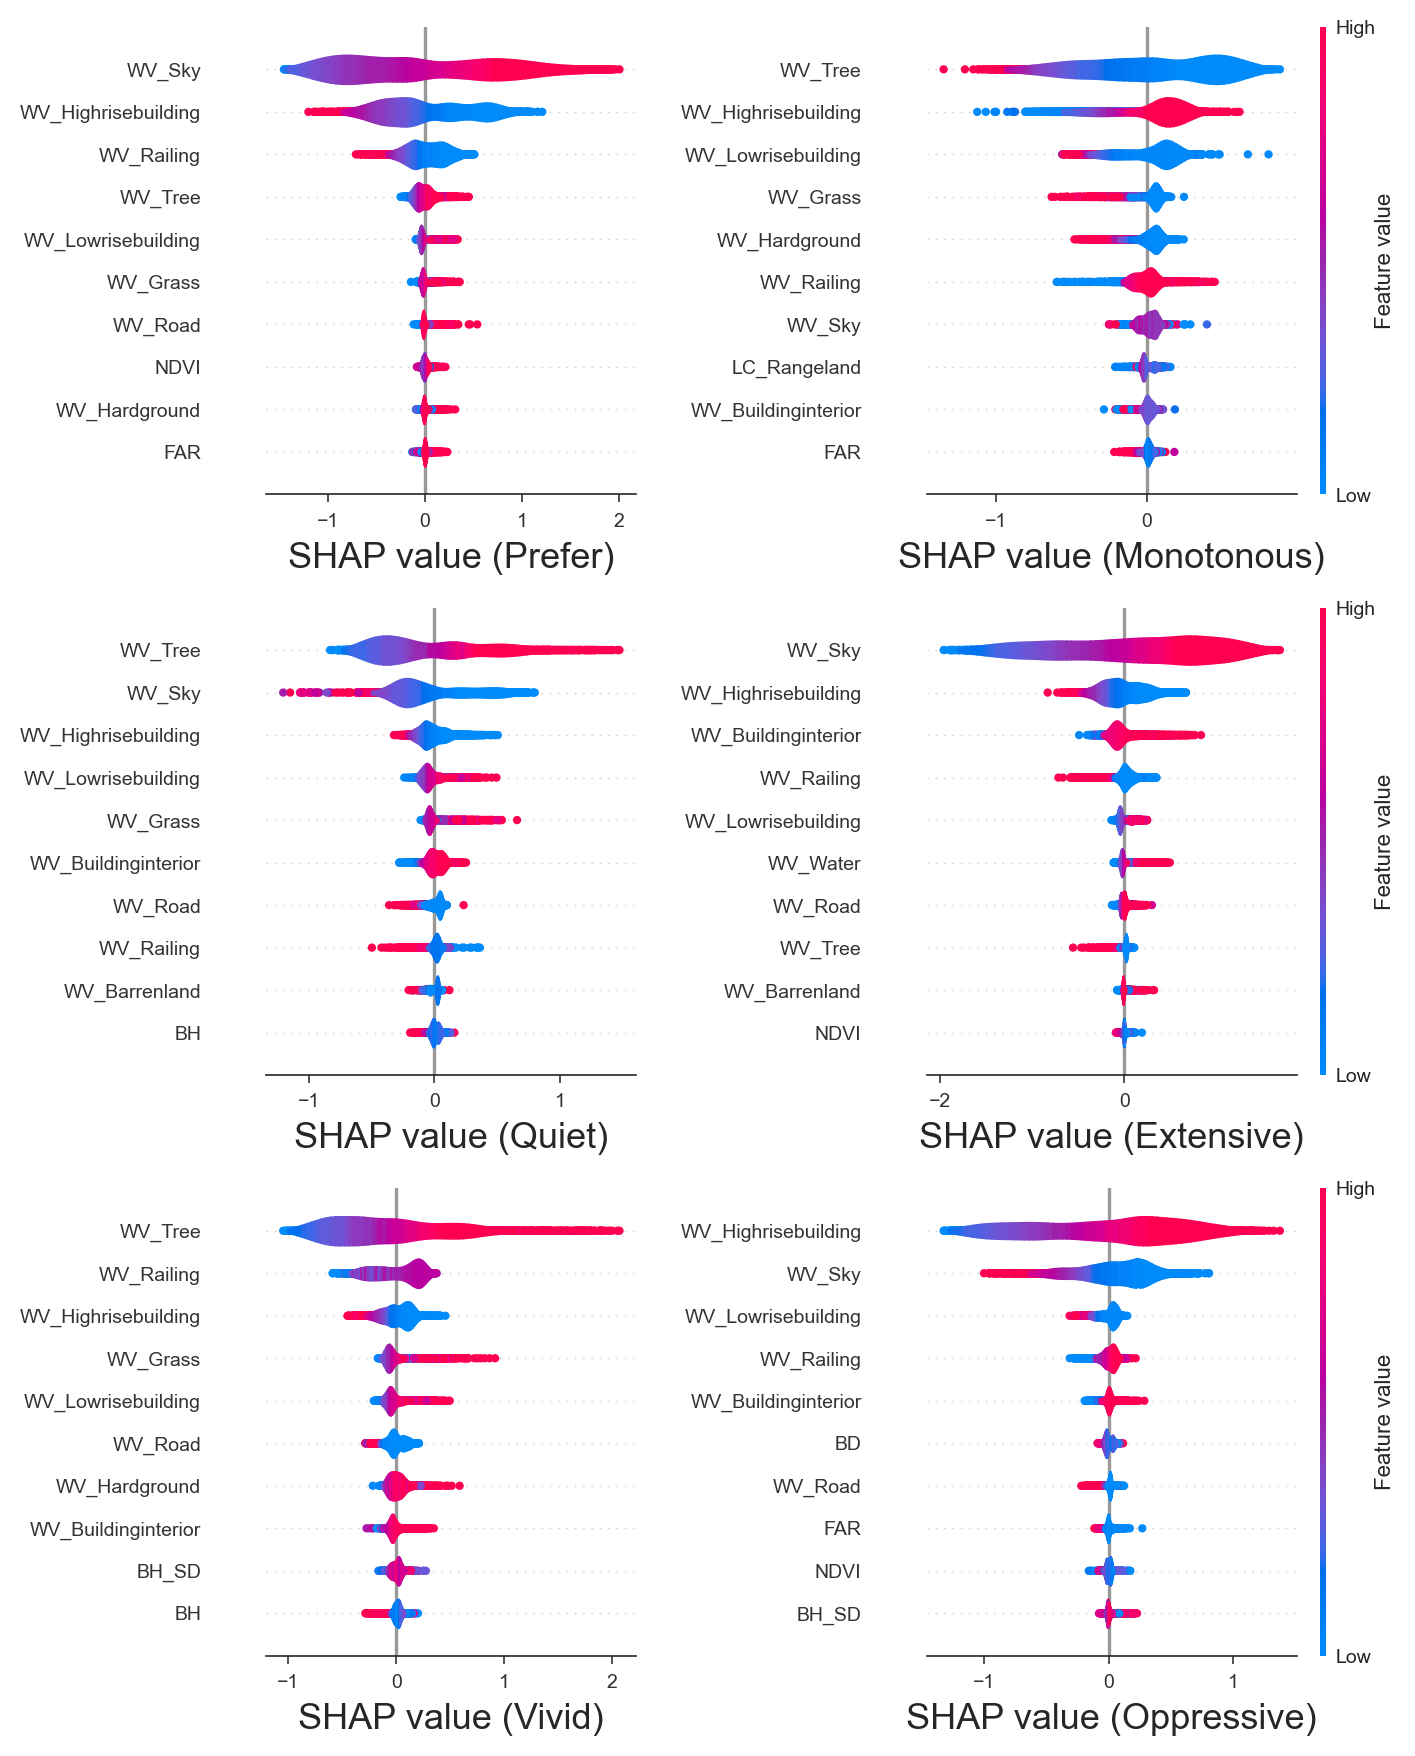

In [ ]:
fig = plt.figure(figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_TALL * 2.6))

for idx, target in enumerate(perception_cols):
    plt.subplot(3, 2, idx + 1)

    shap.summary_plot(
        shap_values_dict[target],
        X_test_raw,
        show=False,
        max_display=10,
        plot_size=None,
        plot_type='violin',
    )

    plt.xlabel(f'SHAP value ({target})')

    for label in plt.gca().get_xticklabels():
        label.set_fontsize(7)
    for label in plt.gca().get_yticklabels():
        label.set_fontsize(7)

    if idx in (1, 3, 5):
        colorbar = plt.gca().figure.axes[-1]
        colorbar.set_ylabel('Feature value', fontsize=8)
        colorbar.set_yticklabels(['Low', 'High'], fontsize=7)
    else:
        plt.gca().get_figure().delaxes(plt.gca().figure.axes[-1])

plt.tight_layout()
Path('figures').mkdir(exist_ok=True)
savefig_all(fig, 'figures/code_6_shap_summary')
plt.show()

#### SHAP Dependence with LOWESS — Computation

For every (perception, feature) pair, a LOWESS smoother is fitted to the SHAP values, and a 95% bootstrap confidence interval is estimated by resampling.

In [ ]:
import statsmodels.api as sm
import pickle


def bootstrap_lowess(x, y, n_iterations=1000, frac=0.3, seed=42):
    """Compute a bootstrap confidence interval for a LOWESS smoother."""
    rng = np.random.default_rng(seed)
    n_samples = len(x)
    predictions = np.zeros((n_iterations, n_samples))

    for i in range(n_iterations):
        indices = rng.integers(0, n_samples, n_samples)
        x_sample = x[indices]
        y_sample = y[indices]

        sort_idx = np.argsort(x_sample)
        x_sorted = x_sample[sort_idx]
        y_sorted = y_sample[sort_idx]

        lowess_result = sm.nonparametric.lowess(
            y_sorted, x_sorted, frac=frac, it=1, delta=0.0
        )
        predictions[i] = np.interp(x, lowess_result[:, 0], lowess_result[:, 1])

    ci_lower = np.percentile(predictions, 2.5, axis=0)
    ci_upper = np.percentile(predictions, 97.5, axis=0)
    return ci_lower, ci_upper


lowess_results = {}

for target in tqdm(perception_cols, desc='Computing LOWESS smoothers'):
    shap_values = shap_values_dict[target]
    for feature in feature_cols:
        feature_idx_in_X = feature_cols.index(feature)
        feature_values = X_test_raw[feature].values
        feature_shap_values = shap_values[:, feature_idx_in_X]

        sort_idx = np.argsort(feature_values)
        x_sorted = feature_values[sort_idx]
        y_sorted = feature_shap_values[sort_idx]

        lowess_result = sm.nonparametric.lowess(
            y_sorted, x_sorted, frac=0.3, it=1, delta=0.0
        )
        x_lowess, y_lowess = lowess_result[:, 0], lowess_result[:, 1]
        ci_lower, ci_upper = bootstrap_lowess(x_sorted, y_sorted)

        lowess_results[(target, feature)] = {
            'x_sorted': x_sorted,
            'y_sorted': y_sorted,
            'x_lowess': x_lowess,
            'y_lowess': y_lowess,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
        }

Path('figures').mkdir(exist_ok=True)
with open('figures/code_6_lowess_results.pkl', 'wb') as f:
    pickle.dump(lowess_results, f)

print(f"Stored LOWESS results for {len(lowess_results)} (perception, feature) pairs.")

Computing LOWESS smoothers:   0%|          | 0/6 [01:36<?, ?it/s]


KeyboardInterrupt: 

#### SHAP Dependence with LOWESS — Visualisation

For each feature, a 2×3 grid shows the SHAP dependence plot across the six perception dimensions, overlaid with the LOWESS smoother and its 95% bootstrap confidence band.

In [ ]:
scatter_color = '#3498db'
line_color = '#e74c3c'
ci_color = '#e74c3c'

shap_fig_dir = Path('figures/code_6_shap_lowess')
shap_fig_dir.mkdir(parents=True, exist_ok=True)

for feature in feature_cols:
    fig, axes = plt.subplots(
        2, 3, figsize=(DOUBLE_COL_WIDTH, FIG_HEIGHT_MEDIUM * 1.6)
    )
    axes = axes.ravel()

    for idx, target in enumerate(perception_cols):
        ax = axes[idx]
        result = lowess_results[(target, feature)]
        x_sorted = result['x_sorted']
        y_sorted = result['y_sorted']
        x_lowess = result['x_lowess']
        y_lowess = result['y_lowess']
        ci_lower = result['ci_lower']
        ci_upper = result['ci_upper']

        ax.fill_between(
            x_sorted, ci_lower, ci_upper,
            color=ci_color, alpha=0.2, label='95% CI',
        )
        ax.scatter(
            x_sorted, y_sorted,
            alpha=0.4, s=12,
            c=scatter_color, edgecolor='white', linewidth=0.4,
            label='SHAP value',
        )
        ax.plot(
            x_lowess, y_lowess,
            color=line_color, linewidth=1.6, label='LOWESS',
        )
        ax.axhline(
            y=0, color='red', linestyle='--', linewidth=0.8,
            alpha=0.7, label='SHAP = 0',
        )

        ax.set_xlabel(f'{feature} ({target})')
        if idx % 3 == 0:
            ax.set_ylabel('SHAP value')

        ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if idx == 0:
            ax.legend(fontsize=6, frameon=False)

    fig.suptitle(f'SHAP dependence — {feature}', fontsize=9)
    plt.tight_layout()
    savefig_all(fig, str(shap_fig_dir / f'shap_lowess_{feature}'))
    plt.show()